In [1]:
# =========================================
# CELDA 2 — Descarga del dataset (separada)
# =========================================

import kagglehub
from pathlib import Path

PROJECT_ROOT = Path.cwd()
RAW_ROOT = PROJECT_ROOT / "data" / "raw"
RAW_ROOT.mkdir(parents=True, exist_ok=True)

# Download latest version
path = Path(kagglehub.dataset_download("thedatasith/sku110k-annotations"))

print("Path to dataset files:", path)
print("Project root:", PROJECT_ROOT)

100%|██████████| 13.2G/13.2G [05:57<00:00, 39.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/thedatasith/sku110k-annotations/versions/14
Project root: /content


In [3]:
# =========================================
# CELDA 1 — Instalación de dependencias
# =========================================
# Ejecutar solo una vez por entorno.

!pip -q install kagglehub ultralytics torchmetrics pycocotools opencv-python pillow pyyaml tqdm

# Si se usa Windows local y pycocotools falla, probar esta alternativa:
# !pip -q install pycocotools-windows

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 71.6 MB/s eta 0:00:00


In [4]:
# =========================================
# CELDA 3 — Imports, configuración y semillas
# =========================================

import os
import json
import math
import time
import yaml
import shutil
import random
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.ops import box_iou

from torchmetrics.detection.mean_ap import MeanAveragePrecision
from ultralytics import YOLO
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CPU_DEVICE = "cpu"
NUM_WORKERS = 0 if os.name == "nt" else 2

# Rutas del proyecto
PROJECT_ROOT = Path.cwd()
RAW_ROOT = PROJECT_ROOT / "data" / "raw"
DATASET_ROOT = Path(path) if "path" in globals() else RAW_ROOT

PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed" / "visorshelf_subset"
IMAGES_OUT = PROCESSED_ROOT / "images"
LABELS_OUT = PROCESSED_ROOT / "labels"
ANNOT_OUT = PROCESSED_ROOT / "annotations"
REPORTS_OUT = PROJECT_ROOT / "reports"
CKPT_OUT = PROJECT_ROOT / "checkpoints"
RUNS_OUT = PROJECT_ROOT / "runs"

for p in [PROCESSED_ROOT, IMAGES_OUT, LABELS_OUT, ANNOT_OUT, REPORTS_OUT, CKPT_OUT, RUNS_OUT]:
    p.mkdir(parents=True, exist_ok=True)

# Tamaños mínimos requeridos
SUBSET_TARGETS = {
    "train": 500,
    "val": 100,
    "test": 100
}

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
# =========================================
# CELDA 4 — Parser correcto para SKU110K en formato YOLO
# =========================================

import yaml
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm

IMAGE_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

DATASET_ROOT = Path(path) if "path" in globals() else Path.cwd()

# En este dataset real, todo está dentro de SKU110K_fixed
YOLO_ROOT = DATASET_ROOT / "SKU110K_fixed"

if not YOLO_ROOT.exists():
    raise FileNotFoundError(f"No se encontró la carpeta esperada: {YOLO_ROOT}")

print("YOLO_ROOT:", YOLO_ROOT)

def build_image_index(search_roots):
    index = {}
    for root in search_roots:
        root = Path(root)
        if not root.exists():
            continue
        for p in root.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
                index[p.name] = p
                index[p.stem] = p
    return index

def load_class_names():
    yaml_candidates = [
        DATASET_ROOT / "data_kaggle.yaml",
        YOLO_ROOT / "data.yaml",
        YOLO_ROOT / "dataset.yaml",
    ]

    for yp in yaml_candidates:
        if yp.exists():
            with open(yp, "r", encoding="utf-8") as f:
                data = yaml.safe_load(f)

            names = data.get("names", None)

            if isinstance(names, list):
                return {i: str(n) for i, n in enumerate(names)}

            if isinstance(names, dict):
                return {int(k): str(v) for k, v in names.items()}

    # fallback
    return {0: "product"}

def resolve_split_dirs(root: Path):
    split_aliases = {
        "train": ["train", "training"],
        "val": ["val", "valid", "validation"],
        "test": ["test", "testing"],
    }

    image_dirs = {}
    label_dirs = {}

    for split, aliases in split_aliases.items():
        found_img = None
        found_lbl = None

        for a in aliases:
            img_dir = root / "images" / a
            lbl_dir = root / "labels" / a

            if img_dir.exists():
                found_img = img_dir
            if lbl_dir.exists():
                found_lbl = lbl_dir

            if found_img is not None and found_lbl is not None:
                break

        if found_img is None or found_lbl is None:
            raise FileNotFoundError(
                f"No se encontraron carpetas YOLO para split='{split}'. "
                f"Esperado algo como {root / 'images'} y {root / 'labels'}"
            )

        image_dirs[split] = found_img
        label_dirs[split] = found_lbl

    return image_dirs, label_dirs

def yolo_split_to_df(image_dir: Path, label_dir: Path, class_map):
    rows = []

    label_files = sorted(label_dir.glob("*.txt"))
    if len(label_files) == 0:
        raise FileNotFoundError(f"No se encontraron labels .txt en {label_dir}")

    for lbl in tqdm(label_files, desc=f"Leyendo {label_dir.name}"):
        stem = lbl.stem

        img_path = None
        for ext in IMAGE_EXTS:
            candidate = image_dir / f"{stem}{ext}"
            if candidate.exists():
                img_path = candidate
                break

        if img_path is None:
            continue

        with Image.open(img_path) as im:
            width, height = im.size

        with open(lbl, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]

        for line in lines:
            parts = line.split()
            if len(parts) < 5:
                continue

            cls_id = int(float(parts[0]))
            cx = float(parts[1]) * width
            cy = float(parts[2]) * height
            bw = float(parts[3]) * width
            bh = float(parts[4]) * height

            x1 = max(0.0, cx - bw / 2.0)
            y1 = max(0.0, cy - bh / 2.0)
            x2 = min(float(width), cx + bw / 2.0)
            y2 = min(float(height), cy + bh / 2.0)

            rows.append({
                "image_name": img_path.name,
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "class_name": class_map.get(cls_id, f"class_{cls_id}"),
                "image_width": width,
                "image_height": height
            })

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError(f"No se pudieron construir anotaciones desde {label_dir}")

    return df

def sample_images_for_split(df, n, seed=42):
    unique_imgs = sorted(df["image_name"].unique())
    if len(unique_imgs) < n:
        raise ValueError(f"El split tiene solo {len(unique_imgs)} imágenes y se pidieron {n}")
    rng = np.random.default_rng(seed)
    chosen = rng.choice(unique_imgs, size=n, replace=False)
    return sorted(chosen)

SEARCH_ROOTS = [YOLO_ROOT, DATASET_ROOT, Path.cwd()]
image_index = build_image_index(SEARCH_ROOTS)

class_map = load_class_names()
print("Class map:", class_map)

image_dirs, label_dirs = resolve_split_dirs(YOLO_ROOT)

raw_dfs = {}
for split in ["train", "val", "test"]:
    df_split = yolo_split_to_df(image_dirs[split], label_dirs[split], class_map)
    raw_dfs[split] = df_split

    print(
        f"{split}: {df_split['image_name'].nunique()} imágenes | "
        f"{len(df_split)} cajas | "
        f"dir imágenes: {image_dirs[split]} | "
        f"dir labels: {label_dirs[split]}"
    )

YOLO_ROOT: /root/.cache/kagglehub/datasets/thedatasith/sku110k-annotations/versions/14/SKU110K_fixed
Class map: {0: 'object'}


Leyendo train: 100%|██████████| 8185/8185 [00:18<00:00, 447.12it/s] 


train: 8185 imágenes | 1203268 cajas | dir imágenes: /root/.cache/kagglehub/datasets/thedatasith/sku110k-annotations/versions/14/SKU110K_fixed/images/train | dir labels: /root/.cache/kagglehub/datasets/thedatasith/sku110k-annotations/versions/14/SKU110K_fixed/labels/train


Leyendo val: 100%|██████████| 584/584 [00:00<00:00, 1215.15it/s]


val: 584 imágenes | 90456 cajas | dir imágenes: /root/.cache/kagglehub/datasets/thedatasith/sku110k-annotations/versions/14/SKU110K_fixed/images/val | dir labels: /root/.cache/kagglehub/datasets/thedatasith/sku110k-annotations/versions/14/SKU110K_fixed/labels/val


Leyendo test: 100%|██████████| 2920/2920 [00:06<00:00, 440.74it/s]


test: 2920 imágenes | 429411 cajas | dir imágenes: /root/.cache/kagglehub/datasets/thedatasith/sku110k-annotations/versions/14/SKU110K_fixed/images/test | dir labels: /root/.cache/kagglehub/datasets/thedatasith/sku110k-annotations/versions/14/SKU110K_fixed/labels/test


In [8]:
# =========================================
# CELDA 5 — Crear subconjunto, copiar imágenes, generar YOLO TXT y COCO JSON
# Compatible con la nueva CELDA 4 en Colab
# =========================================

import json
import shutil
import yaml
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# Targets mínimos requeridos
SUBSET_TARGETS = {
    "train": 500,
    "val": 100,
    "test": 100
}

# Rutas de salida
PROJECT_ROOT = Path.cwd()
PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed" / "visorshelf_subset"
IMAGES_OUT = PROCESSED_ROOT / "images"
LABELS_OUT = PROCESSED_ROOT / "labels"
ANNOT_OUT = PROCESSED_ROOT / "annotations"
REPORTS_OUT = PROJECT_ROOT / "reports"

for p in [PROCESSED_ROOT, IMAGES_OUT, LABELS_OUT, ANNOT_OUT, REPORTS_OUT]:
    p.mkdir(parents=True, exist_ok=True)

# Muestreo del subconjunto
selected_images = {}
subset_dfs = {}

for split in ["train", "val", "test"]:
    chosen = sample_images_for_split(raw_dfs[split], SUBSET_TARGETS[split])
    selected_images[split] = chosen
    subset_dfs[split] = raw_dfs[split][raw_dfs[split]["image_name"].isin(chosen)].copy()

# Clases
classes = sorted(subset_dfs["train"]["class_name"].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(classes)}       # 0-based para YOLO / evaluación
class_to_coco = {c: i + 1 for i, c in enumerate(classes)}  # 1-based para COCO / Faster R-CNN
primary_class = subset_dfs["train"]["class_name"].value_counts().idxmax()

print("Clases detectadas:", classes)
print("Clase principal:", primary_class)

# Crear estructura de carpetas
for split in ["train", "val", "test"]:
    (IMAGES_OUT / split).mkdir(parents=True, exist_ok=True)
    (LABELS_OUT / split).mkdir(parents=True, exist_ok=True)

summary_rows = []

for split in ["train", "val", "test"]:
    df = subset_dfs[split].copy()

    coco = {
        "images": [],
        "annotations": [],
        "categories": [{"id": class_to_coco[c], "name": c} for c in classes]
    }

    ann_id = 1
    img_id_map = {img_name: i + 1 for i, img_name in enumerate(sorted(df["image_name"].unique()))}

    for img_name in tqdm(sorted(df["image_name"].unique()), desc=f"Exportando {split}"):
        # Buscar path real de imagen
        img_path = image_index.get(img_name) or image_index.get(Path(img_name).stem)
        if img_path is None:
            raise FileNotFoundError(f"No se encontró la imagen '{img_name}' en image_index.")

        # Copiar imagen al subconjunto
        dst_img = IMAGES_OUT / split / Path(img_name).name
        if not dst_img.exists():
            shutil.copy2(img_path, dst_img)

        img_rows = df[df["image_name"] == img_name].copy()
        width = int(img_rows["image_width"].iloc[0])
        height = int(img_rows["image_height"].iloc[0])

        coco["images"].append({
            "id": img_id_map[img_name],
            "file_name": Path(img_name).name,
            "width": width,
            "height": height
        })

        yolo_lines = []

        for _, row in img_rows.iterrows():
            cls_name = row["class_name"]
            cls_yolo = class_to_idx[cls_name]
            cls_coco = class_to_coco[cls_name]

            x1, y1, x2, y2 = map(float, [row["x1"], row["y1"], row["x2"], row["y2"]])
            bw = x2 - x1
            bh = y2 - y1
            cx = x1 + bw / 2.0
            cy = y1 + bh / 2.0

            # YOLO TXT normalizado
            yolo_lines.append(
                f"{cls_yolo} {cx/width:.6f} {cy/height:.6f} {bw/width:.6f} {bh/height:.6f}"
            )

            # COCO JSON
            coco["annotations"].append({
                "id": ann_id,
                "image_id": img_id_map[img_name],
                "category_id": cls_coco,
                "bbox": [x1, y1, bw, bh],
                "area": bw * bh,
                "iscrowd": 0
            })
            ann_id += 1

            summary_rows.append({
                "split": split,
                "image_name": Path(img_name).name,
                "class_name": cls_name
            })

        # Guardar label TXT
        label_path = LABELS_OUT / split / f"{Path(img_name).stem}.txt"
        with open(label_path, "w", encoding="utf-8") as f:
            f.write("\n".join(yolo_lines))

    # Guardar COCO JSON del split
    with open(ANNOT_OUT / f"{split}.json", "w", encoding="utf-8") as f:
        json.dump(coco, f, ensure_ascii=False)

# Guardar YAML para YOLO
dataset_yaml = {
    "path": str(PROCESSED_ROOT),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": len(classes),
    "names": {i: c for i, c in enumerate(classes)}
}

with open(PROCESSED_ROOT / "dataset.yaml", "w", encoding="utf-8") as f:
    yaml.safe_dump(dataset_yaml, f, sort_keys=False, allow_unicode=True)

# Distribución de clases
summary_df = pd.DataFrame(summary_rows)
class_dist = (
    summary_df.groupby(["split", "class_name"])
    .size()
    .reset_index(name="instances")
    .sort_values(["split", "instances"], ascending=[True, False])
)

display(class_dist)

summary_df.to_csv(REPORTS_OUT / "subset_instances.csv", index=False)
class_dist.to_csv(REPORTS_OUT / "class_distribution.csv", index=False)

print("Dataset procesado en:", PROCESSED_ROOT)
print("YAML:", PROCESSED_ROOT / "dataset.yaml")
print("COCO train:", ANNOT_OUT / "train.json")

Clases detectadas: ['object']
Clase principal: object


Exportando test: 100%|██████████| 100/100 [00:02<00:00, 40.18it/s]


,split,class_name,instances
0,test,object,14138
1,train,object,74755
2,val,object,17006


Dataset procesado en: /content/data/processed/visorshelf_subset
YAML: /content/data/processed/visorshelf_subset/dataset.yaml
COCO train: /content/data/processed/visorshelf_subset/annotations/train.json


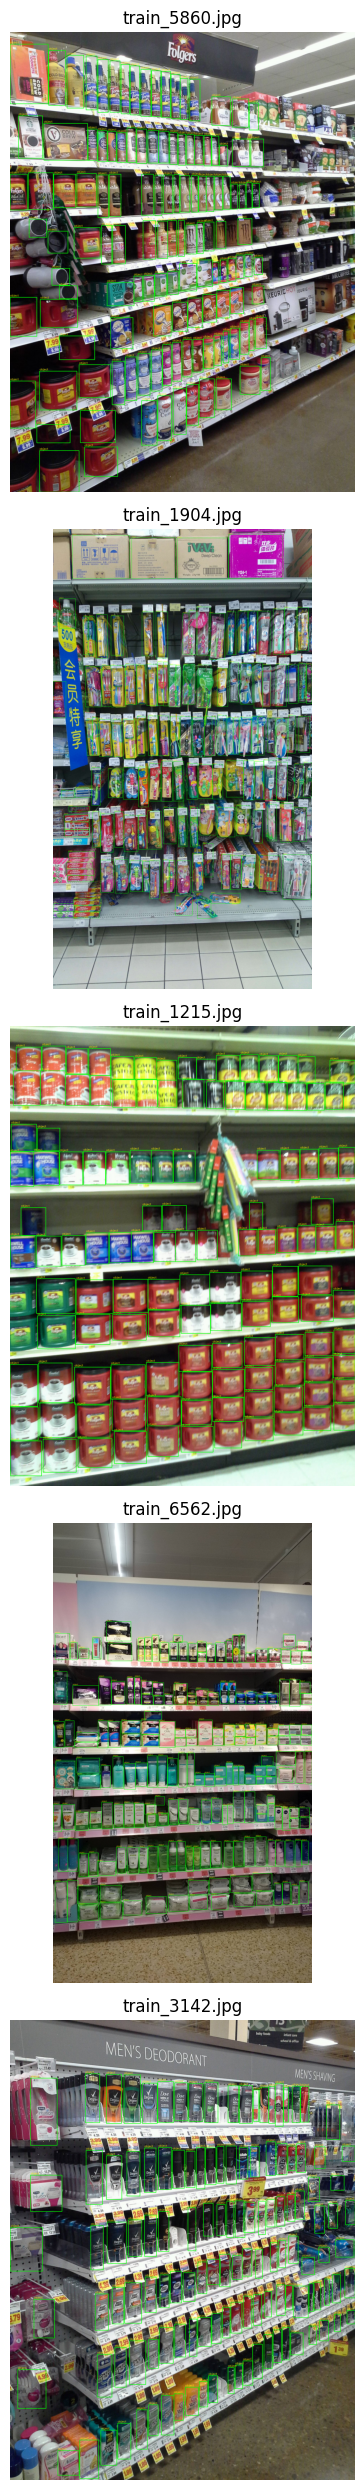

In [9]:
# =========================================
# CELDA 6 — Visualizar 5 imágenes anotadas antes del entrenamiento
# =========================================

def draw_gt(image_path, boxes, labels=None):
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        if labels is not None:
            cv2.putText(
                img,
                str(labels[i]),
                (x1, max(15, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255, 255, 0),
                1,
                cv2.LINE_AA
            )
    return img


sample_imgs = random.sample(selected_images["train"], 5)

fig, axes = plt.subplots(len(sample_imgs), 1, figsize=(14, 5 * len(sample_imgs)))
if len(sample_imgs) == 1:
    axes = [axes]

for ax, img_name in zip(axes, sample_imgs):
    img_path = IMAGES_OUT / "train" / img_name
    rows = subset_dfs["train"][subset_dfs["train"]["image_name"] == img_name]
    boxes = rows[["x1", "y1", "x2", "y2"]].values
    labels = rows["class_name"].tolist()

    vis = draw_gt(img_path, boxes, labels)
    ax.imshow(vis)
    ax.set_title(img_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# =========================================
# CELDA 7 — Dataset y utilidades para Faster R-CNN
# =========================================

class COCODetectionDataset(Dataset):
    def __init__(self, annotation_json, image_dir):
        self.image_dir = Path(image_dir)

        with open(annotation_json, "r", encoding="utf-8") as f:
            coco = json.load(f)

        self.images = sorted(coco["images"], key=lambda x: x["id"])
        self.ann_by_image = defaultdict(list)
        for ann in coco["annotations"]:
            self.ann_by_image[ann["image_id"]].append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = self.image_dir / img_info["file_name"]

        img = Image.open(img_path).convert("RGB")
        img_tensor = TF.to_tensor(img)

        anns = self.ann_by_image.get(img_info["id"], [])
        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for ann in anns:
            x, y, w, h = ann["bbox"]
            boxes.append([x, y, x + w, y + h])
            labels.append(ann["category_id"])   # 1-based para Faster R-CNN
            areas.append(ann["area"])
            iscrowd.append(ann.get("iscrowd", 0))

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([img_info["id"]], dtype=torch.int64),
            "area": torch.tensor(areas, dtype=torch.float32),
            "iscrowd": torch.tensor(iscrowd, dtype=torch.int64),
            "file_name": img_info["file_name"]
        }

        return img_tensor, target, str(img_path)


def collate_fn(batch):
    images, targets, paths = zip(*batch)
    return list(images), list(targets), list(paths)


train_ds = COCODetectionDataset(ANNOT_OUT / "train.json", IMAGES_OUT / "train")
val_ds = COCODetectionDataset(ANNOT_OUT / "val.json", IMAGES_OUT / "val")
test_ds = COCODetectionDataset(ANNOT_OUT / "test.json", IMAGES_OUT / "test")

train_loader = DataLoader(
    train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_ds,
    batch_size=2,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=torch.cuda.is_available()
)

def get_faster_model(num_classes):
    model = fasterrcnn_resnet50_fpn_v2(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


def train_one_epoch_faster(model, loader, optimizer, device, scaler=None):
    model.train()
    losses_epoch = []

    for images, targets, _ in tqdm(loader, desc="Entrenando Faster R-CNN", leave=False):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) if torch.is_tensor(v) else v for k, v in t.items()} for t in targets]

        optimizer.zero_grad(set_to_none=True)

        if scaler is not None and torch.cuda.is_available():
            with torch.cuda.amp.autocast():
                loss_dict = model(images, targets)
                loss = sum(v for v in loss_dict.values())
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss_dict = model(images, targets)
            loss = sum(v for v in loss_dict.values())
            loss.backward()
            optimizer.step()

        losses_epoch.append(loss.item())

    return float(np.mean(losses_epoch))


@torch.inference_mode()
def evaluate_map_faster(model, loader, device):
    model.eval()
    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")

    for images, targets, _ in tqdm(loader, desc="Validando Faster R-CNN", leave=False):
        images_dev = [img.to(device) for img in images]
        outputs = model(images_dev)

        preds = []
        refs = []

        for output, target in zip(outputs, targets):
            preds.append({
                "boxes": output["boxes"].detach().cpu(),
                "scores": output["scores"].detach().cpu(),
                "labels": (output["labels"].detach().cpu() - 1).clamp(min=0)  # 0-based para evaluación
            })
            refs.append({
                "boxes": target["boxes"].cpu(),
                "labels": (target["labels"].cpu() - 1).clamp(min=0)
            })

        metric.update(preds, refs)

    results = metric.compute()
    return {k: (v.item() if torch.is_tensor(v) else v) for k, v in results.items()}

In [11]:
# =========================================
# CELDA 8 — Entrenamiento Faster R-CNN con backbone congelado al inicio + early stopping
# =========================================

FASTER_NUM_CLASSES = len(classes) + 1   # + background
FASTER_EPOCHS_FROZEN = 3
FASTER_EPOCHS_UNFROZEN = 12
FASTER_PATIENCE = 4

faster_model = get_faster_model(FASTER_NUM_CLASSES).to(DEVICE)

# Fase 1: backbone congelado
for p in faster_model.backbone.parameters():
    p.requires_grad = False

optimizer = torch.optim.SGD(
    [p for p in faster_model.parameters() if p.requires_grad],
    lr=1e-3,
    momentum=0.9,
    weight_decay=5e-4
)

scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

best_map = -1.0
best_epoch = -1
patience_counter = 0
faster_history = []

FASTER_BEST_PATH = CKPT_OUT / "fasterrcnn_resnet50_fpn_v2_best.pth"

total_epochs = FASTER_EPOCHS_FROZEN + FASTER_EPOCHS_UNFROZEN

for epoch in range(1, total_epochs + 1):
    if epoch == FASTER_EPOCHS_FROZEN + 1:
        print("\nDescongelando backbone para la fase 2...\n")
        for p in faster_model.backbone.parameters():
            p.requires_grad = True

        head_params = []
        backbone_params = []

        for name, p in faster_model.named_parameters():
            if p.requires_grad:
                if "backbone" in name:
                    backbone_params.append(p)
                else:
                    head_params.append(p)

        optimizer = torch.optim.SGD(
            [
                {"params": head_params, "lr": 1e-3},
                {"params": backbone_params, "lr": 1e-4},
            ],
            momentum=0.9,
            weight_decay=5e-4
        )

    train_loss = train_one_epoch_faster(faster_model, train_loader, optimizer, DEVICE, scaler=scaler)
    val_metrics = evaluate_map_faster(faster_model, val_loader, DEVICE)

    epoch_log = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_map_50_95": val_metrics["map"],
        "val_map_50": val_metrics["map_50"]
    }
    faster_history.append(epoch_log)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_mAP50={val_metrics['map_50']:.4f} | "
        f"val_mAP50_95={val_metrics['map']:.4f}"
    )

    if val_metrics["map"] > best_map:
        best_map = val_metrics["map"]
        best_epoch = epoch
        patience_counter = 0
        torch.save(faster_model.state_dict(), FASTER_BEST_PATH)
        print(f"  -> Nuevo mejor modelo guardado en: {FASTER_BEST_PATH}")
    else:
        patience_counter += 1
        print(f"  -> Sin mejora. Patience: {patience_counter}/{FASTER_PATIENCE}")

    if patience_counter >= FASTER_PATIENCE:
        print("Early stopping activado para Faster R-CNN.")
        break

faster_history_df = pd.DataFrame(faster_history)
display(faster_history_df)
faster_history_df.to_csv(REPORTS_OUT / "faster_history.csv", index=False)

print("Mejor epoch Faster R-CNN:", best_epoch)
print("Mejor checkpoint:", FASTER_BEST_PATH)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:01<00:00, 147MB/s]
/tmp/ipykernel_12127/4244866781.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
Entrenando Faster R-CNN:   0%|          | 0/250 [00:00<?, ?it/s]/tmp/ipykernel_12127/492137647.py:106: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 01 | train_loss=1.5006 | val_mAP50=0.3268 | val_mAP50_95=0.1484
  -> Nuevo mejor modelo guardado en: /content/checkpoints/fasterrcnn_resnet50_fpn_v2_best.pth


Epoch 02 | train_loss=1.2083 | val_mAP50=0.3656 | val_mAP50_95=0.1724
  -> Nuevo mejor modelo guardado en: /content/checkpoints/fasterrcnn_resnet50_fpn_v2_best.pth


Epoch 03 | train_loss=1.1464 | val_mAP50=0.3898 | val_mAP50_95=0.1873
  -> Nuevo mejor modelo guardado en: /content/checkpoints/fasterrcnn_resnet50_fpn_v2_best.pth

Descongelando backbone para la fase 2...



...

Epoch 13 | train_loss=0.8138 | val_mAP50=0.4900 | val_mAP50_95=0.2694
  -> Sin mejora. Patience: 1/4


Epoch 14 | train_loss=0.8045 | val_mAP50=0.5011 | val_mAP50_95=0.2803
  -> Nuevo mejor modelo guardado en: /content/checkpoints/fasterrcnn_resnet50_fpn_v2_best.pth


Epoch 15 | train_loss=0.7849 | val_mAP50=0.5012 | val_mAP50_95=0.2790
  -> Sin mejora. Patience: 1/4


,epoch,train_loss,val_map_50_95,val_map_50
0,1,1.500605,0.148351,0.326780
1,2,1.208299,0.172390,0.365580
2,3,1.146350,0.187345,0.389798
3,4,1.079780,0.207862,0.417045
4,5,1.016824,0.227495,0.442232
5,6,0.973108,0.237373,0.453811
6,7,0.932604,0.247610,0.466197
7,8,0.907611,0.253453,0.467664
8,9,0.880448,0.257121,0.477841
9,10,0.862012,0.264278,0.480227


Mejor epoch Faster R-CNN: 14
Mejor checkpoint: /content/checkpoints/fasterrcnn_resnet50_fpn_v2_best.pth


In [12]:
# =========================================
# CELDA 9 — Entrenamiento YOLOv8n con capas base congeladas al inicio + early stopping
# =========================================

YOLO_IMGSZ = 640
YOLO_BATCH = 8 if DEVICE == "cuda" else 4
YOLO_EPOCHS_FROZEN = 3
YOLO_EPOCHS_UNFROZEN = 15
YOLO_PATIENCE = 4

YOLO_DATA_YAML = PROCESSED_ROOT / "dataset.yaml"

# Fase 1: primeras capas congeladas
yolo_phase1 = YOLO("yolov8n.pt")
phase1_results = yolo_phase1.train(
    data=str(YOLO_DATA_YAML),
    imgsz=YOLO_IMGSZ,
    epochs=YOLO_EPOCHS_FROZEN,
    batch=YOLO_BATCH,
    device=0 if DEVICE == "cuda" else "cpu",
    freeze=10,
    patience=YOLO_PATIENCE,
    optimizer="AdamW",
    lr0=1e-3,
    project=str(RUNS_OUT),
    name="yolov8n_phase1",
    exist_ok=True,
    workers=NUM_WORKERS,
    verbose=True
)

YOLO_PHASE1_BEST = RUNS_OUT / "yolov8n_phase1" / "weights" / "best.pt"
print("YOLO phase1 best:", YOLO_PHASE1_BEST)

# Fase 2: fine-tuning completo
yolo_phase2 = YOLO(str(YOLO_PHASE1_BEST))
phase2_results = yolo_phase2.train(
    data=str(YOLO_DATA_YAML),
    imgsz=YOLO_IMGSZ,
    epochs=YOLO_EPOCHS_UNFROZEN,
    batch=YOLO_BATCH,
    device=0 if DEVICE == "cuda" else "cpu",
    freeze=0,
    patience=YOLO_PATIENCE,
    optimizer="AdamW",
    lr0=5e-4,
    project=str(RUNS_OUT),
    name="yolov8n_phase2",
    exist_ok=True,
    workers=NUM_WORKERS,
    verbose=True
)

YOLO_BEST_PATH = RUNS_OUT / "yolov8n_phase2" / "weights" / "best.pt"
print("YOLO best:", YOLO_BEST_PATH)

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/processed/visorshelf_subset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_phase1, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, over

In [13]:
# =========================================
# CELDA 10 — Funciones de evaluación comunes: mAP, precision/recall, FPS, tamaño
# =========================================

def empty_pred():
    return {
        "boxes": torch.zeros((0, 4), dtype=torch.float32),
        "scores": torch.zeros((0,), dtype=torch.float32),
        "labels": torch.zeros((0,), dtype=torch.int64)
    }

def greedy_precision_recall(preds_list, targets_list, class_idx, iou_thresh=0.5, conf_thresh=0.25):
    tp, fp, fn = 0, 0, 0

    for pred, target in zip(preds_list, targets_list):
        p_mask = (pred["labels"] == class_idx) & (pred["scores"] >= conf_thresh)
        t_mask = (target["labels"] == class_idx)

        p_boxes = pred["boxes"][p_mask]
        p_scores = pred["scores"][p_mask]
        t_boxes = target["boxes"][t_mask]

        if len(p_boxes) == 0 and len(t_boxes) == 0:
            continue
        if len(p_boxes) == 0:
            fn += len(t_boxes)
            continue
        if len(t_boxes) == 0:
            fp += len(p_boxes)
            continue

        order = torch.argsort(p_scores, descending=True)
        p_boxes = p_boxes[order]

        ious = box_iou(p_boxes, t_boxes)
        matched_gt = set()

        for i in range(p_boxes.shape[0]):
            best_iou = 0.0
            best_j = -1
            for j in range(t_boxes.shape[0]):
                if j in matched_gt:
                    continue
                iou = float(ious[i, j].item())
                if iou > best_iou:
                    best_iou = iou
                    best_j = j

            if best_iou >= iou_thresh and best_j >= 0:
                tp += 1
                matched_gt.add(best_j)
            else:
                fp += 1

        fn += (t_boxes.shape[0] - len(matched_gt))

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    return precision, recall


@torch.inference_mode()
def faster_predict(model, img_tensor, device):
    model.eval()
    output = model([img_tensor.to(device)])[0]
    return {
        "boxes": output["boxes"].detach().cpu(),
        "scores": output["scores"].detach().cpu(),
        "labels": (output["labels"].detach().cpu() - 1).clamp(min=0)
    }


def yolo_predict(model, img_path, device):
    result = model.predict(
        source=str(img_path),
        imgsz=YOLO_IMGSZ,
        conf=0.001,
        device=device,
        verbose=False
    )[0]

    if result.boxes is None or len(result.boxes) == 0:
        return empty_pred()

    return {
        "boxes": result.boxes.xyxy.detach().cpu(),
        "scores": result.boxes.conf.detach().cpu(),
        "labels": result.boxes.cls.detach().cpu().to(torch.int64)
    }


def evaluate_detector_on_dataset(detector_name, predict_fn, dataset, primary_class_idx):
    map_metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")
    preds_all = []
    targets_all = []

    for i in tqdm(range(len(dataset)), desc=f"Evaluando {detector_name}"):
        img_tensor, target, img_path = dataset[i]
        pred = predict_fn(img_tensor, img_path)

        gt = {
            "boxes": target["boxes"].cpu(),
            "labels": (target["labels"].cpu() - 1).clamp(min=0)
        }

        map_metric.update([pred], [gt])
        preds_all.append(pred)
        targets_all.append(gt)

    metrics = map_metric.compute()
    precision, recall = greedy_precision_recall(
        preds_all,
        targets_all,
        class_idx=primary_class_idx,
        iou_thresh=0.5,
        conf_thresh=0.25
    )

    return {
        "model": detector_name,
        "mAP@0.5": float(metrics["map_50"].item()),
        "mAP@0.5:0.95": float(metrics["map"].item()),
        "precision_primary": float(precision),
        "recall_primary": float(recall)
    }


def benchmark_fps_faster_cpu(model_path, num_classes, sample_paths):
    model = get_faster_model(num_classes)
    model.load_state_dict(torch.load(model_path, map_location="cpu"))
    model.to("cpu").eval()

    timings = []
    warmup = min(5, len(sample_paths))
    measure_paths = sample_paths[:50]

    with torch.inference_mode():
        for p in sample_paths[:warmup]:
            img = TF.to_tensor(Image.open(p).convert("RGB"))
            _ = model([img])

        for p in tqdm(measure_paths, desc="Benchmark Faster R-CNN CPU", leave=False):
            img = TF.to_tensor(Image.open(p).convert("RGB"))
            start = time.perf_counter()
            _ = model([img])
            end = time.perf_counter()
            timings.append(end - start)

    avg_time = float(np.mean(timings))
    fps = 1.0 / avg_time if avg_time > 0 else 0.0
    return fps, avg_time


def benchmark_fps_yolo_cpu(model_path, sample_paths):
    model = YOLO(str(model_path))

    timings = []
    warmup = min(5, len(sample_paths))
    measure_paths = sample_paths[:50]

    for p in sample_paths[:warmup]:
        _ = model.predict(source=str(p), imgsz=YOLO_IMGSZ, conf=0.25, device="cpu", verbose=False)

    for p in tqdm(measure_paths, desc="Benchmark YOLO CPU", leave=False):
        start = time.perf_counter()
        _ = model.predict(source=str(p), imgsz=YOLO_IMGSZ, conf=0.25, device="cpu", verbose=False)
        end = time.perf_counter()
        timings.append(end - start)

    avg_time = float(np.mean(timings))
    fps = 1.0 / avg_time if avg_time > 0 else 0.0
    return fps, avg_time


def file_size_mb(path):
    return Path(path).stat().st_size / (1024 * 1024)

In [14]:
# =========================================
# CELDA 11 — Evaluación final en test: ambos modelos
# =========================================

PRIMARY_CLASS_IDX = class_to_idx[primary_class]

# Cargar Faster R-CNN mejor checkpoint
faster_best_model = get_faster_model(FASTER_NUM_CLASSES)
faster_best_model.load_state_dict(torch.load(FASTER_BEST_PATH, map_location=DEVICE))
faster_best_model.to(DEVICE).eval()

# Cargar YOLO mejor checkpoint
yolo_best_model = YOLO(str(YOLO_BEST_PATH))

# Wrappers
faster_fn = lambda img_tensor, img_path: faster_predict(faster_best_model, img_tensor, DEVICE)
yolo_fn = lambda img_tensor, img_path: yolo_predict(yolo_best_model, img_path, 0 if DEVICE == "cuda" else "cpu")

# Métricas principales
faster_metrics = evaluate_detector_on_dataset("Faster R-CNN ResNet50-FPNv2", faster_fn, test_ds, PRIMARY_CLASS_IDX)
yolo_metrics = evaluate_detector_on_dataset("YOLOv8n", yolo_fn, test_ds, PRIMARY_CLASS_IDX)

# FPS en CPU sobre 50 imágenes
sample_test_paths = [Path(test_ds[i][2]) for i in range(min(50, len(test_ds)))]

faster_fps, faster_avg_time = benchmark_fps_faster_cpu(FASTER_BEST_PATH, FASTER_NUM_CLASSES, sample_test_paths)
yolo_fps, yolo_avg_time = benchmark_fps_yolo_cpu(YOLO_BEST_PATH, sample_test_paths)

faster_metrics["fps_cpu_50img"] = faster_fps
faster_metrics["avg_inference_time_s_cpu"] = faster_avg_time
faster_metrics["model_size_mb"] = file_size_mb(FASTER_BEST_PATH)

yolo_metrics["fps_cpu_50img"] = yolo_fps
yolo_metrics["avg_inference_time_s_cpu"] = yolo_avg_time
yolo_metrics["model_size_mb"] = file_size_mb(YOLO_BEST_PATH)

metrics_df = pd.DataFrame([faster_metrics, yolo_metrics])

# Cálculo MB por punto de mAP (usando mAP@0.5:0.95)
metrics_df["MB_por_punto_mAP50_95"] = metrics_df["model_size_mb"] / (metrics_df["mAP@0.5:0.95"] * 100 + 1e-9)

display(metrics_df)
metrics_df.to_csv(REPORTS_OUT / "metrics_summary.csv", index=False)

print("Resultados guardados en:", REPORTS_OUT / "metrics_summary.csv")

Evaluando YOLOv8n:   0%|          | 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)
Evaluando YOLOv8n: 100%|██████████| 100/100 [00:40<00:00,  2.45it/s]


,model,mAP@0.5,mAP@0.5:0.95,precision_primary,recall_primary,fps_cpu_50img,avg_inference_time_s_cpu,model_size_mb,MB_por_punto_mAP50_95
0,Faster R-CNN ResNet50-FPNv2,0.599835,0.348188,0.867100,0.613312,0.105357,9.491502,165.380500,4.749750
1,YOLOv8n,0.582735,0.349831,0.686753,0.804499,6.520117,0.153371,5.932901,0.169593


Resultados guardados en: /content/reports/metrics_summary.csv


Mejor modelo según mAP@0.5:0.95: YOLOv8n


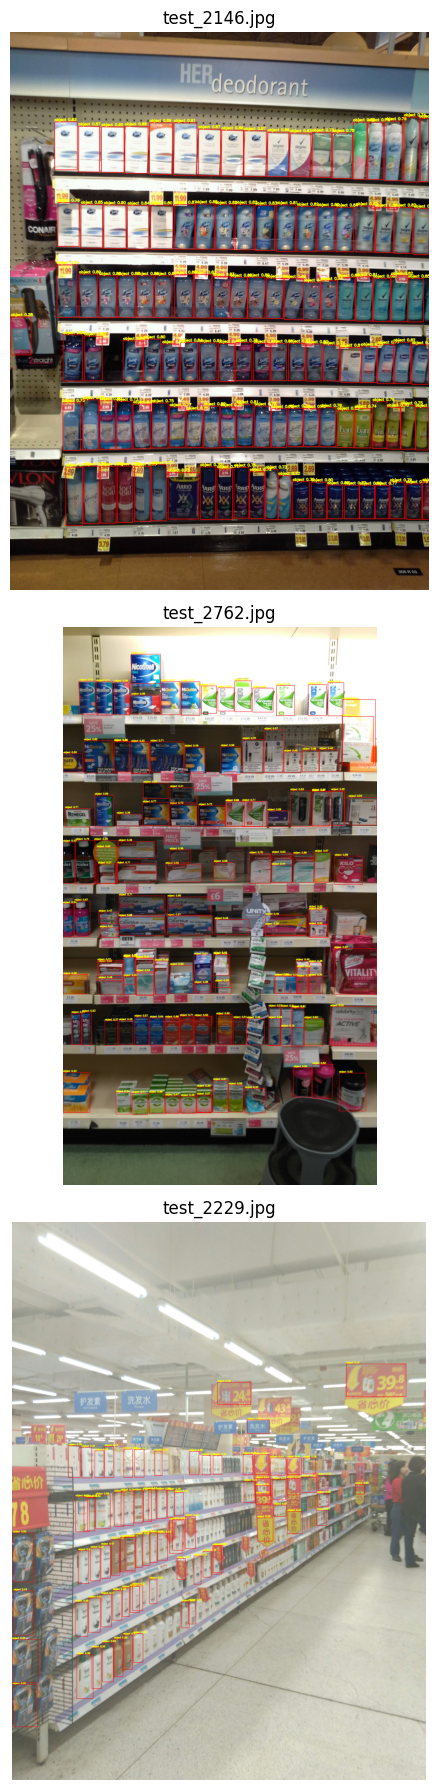

In [15]:
# =========================================
# CELDA 12 — Visualizar 3 imágenes de prueba con detecciones del mejor modelo
# =========================================

best_model_name = metrics_df.sort_values("mAP@0.5:0.95", ascending=False).iloc[0]["model"]
print("Mejor modelo según mAP@0.5:0.95:", best_model_name)

if best_model_name == "YOLOv8n":
    best_predict_fn = yolo_fn
else:
    best_predict_fn = faster_fn

def draw_predictions(image_path, pred, class_names, conf_thresh=0.25):
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    boxes = pred["boxes"].numpy()
    scores = pred["scores"].numpy()
    labels = pred["labels"].numpy()

    for box, score, label in zip(boxes, scores, labels):
        if score < conf_thresh:
            continue

        x1, y1, x2, y2 = map(int, box)
        cls_name = class_names[int(label)] if int(label) < len(class_names) else str(label)
        text = f"{cls_name} {score:.2f}"

        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(
            img,
            text,
            (x1, max(15, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 255, 0),
            2,
            cv2.LINE_AA
        )
    return img

sample_indices = random.sample(range(len(test_ds)), 3)

fig, axes = plt.subplots(len(sample_indices), 1, figsize=(14, 6 * len(sample_indices)))
if len(sample_indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, sample_indices):
    img_tensor, target, img_path = test_ds[idx]
    pred = best_predict_fn(img_tensor, img_path)
    vis = draw_predictions(img_path, pred, classes, conf_thresh=0.25)

    ax.imshow(vis)
    ax.set_title(Path(img_path).name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# =========================================
# CELDA 13 — Resumen extra útil para el reporte
# =========================================

summary_for_report = metrics_df.copy()
summary_for_report["imagenes_por_hora_1_camara"] = summary_for_report["fps_cpu_50img"] * 3600
summary_for_report["imagenes_por_hora_5_camaras"] = summary_for_report["fps_cpu_50img"] * 3600 / 5
summary_for_report["cumple_1_imagen_cada_30s"] = summary_for_report["avg_inference_time_s_cpu"] <= 30.0

display(summary_for_report)
summary_for_report.to_csv(REPORTS_OUT / "summary_for_report.csv", index=False)

,model,mAP@0.5,mAP@0.5:0.95,precision_primary,recall_primary,fps_cpu_50img,avg_inference_time_s_cpu,model_size_mb,MB_por_punto_mAP50_95,imagenes_por_hora_1_camara,imagenes_por_hora_5_camaras,cumple_1_imagen_cada_30s
0,Faster R-CNN ResNet50-FPNv2,0.599835,0.348188,0.867100,0.613312,0.105357,9.491502,165.380500,4.749750,379.286663,75.857333,True
1,YOLOv8n,0.582735,0.349831,0.686753,0.804499,6.520117,0.153371,5.932901,0.169593,23472.420155,4694.484031,True
